In [2]:
%%capture output
! pip install ibllib
! pip install pynapple
! pip install git+https://github.com/int-brain-lab/paper-brain-wide-map.git
! pip install -U google-colab

In [3]:
# system
from pathlib import Path
from tqdm import tqdm
import pickle

# analysis
import numpy as np
import pandas as pd
import pynapple as nap
from scipy import stats
import glob 
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score
import warnings
import os

# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.ndimage import gaussian_filter1d
import statsmodels.formula.api as smf
import statsmodels.api as sm
from statsmodels.formula.api import mixedlm


# set the IBL style for figures
# from ibl_style.style import figure_style
# figure_style()
from reproducible_ephys_functions import get_insertions
from functions import idxs_from_files
from one.api import ONE
one= ONE()

In [4]:
prefix = '/home/ines/repositories/'
# prefix = '/Users/ineslaranjeira/Documents/Repositories/'


# Load trial data

In [5]:
data_path = prefix + 'representation_learning_variability/paper-individuality/clustering/'
# session_cluster = pd.read_parquet(data_path+'cluster_per_session')
trial_modes = pd.read_parquet(data_path+'18_trial_waterclust')
trial_modes = trial_modes[['session', 'sample', 'trial_cluster']].drop_duplicates()
trial_modes['index'] = trial_modes['sample'].str.split().str[1:2].str.join('').astype(float)
trial_modes = trial_modes.rename(columns={'index':'trial_id', 'session':'eid'})

In [6]:
insertions = get_insertions(level=0, one=one, freeze='freeze_2024_03')
repro_ephys_insertions = pd.DataFrame.from_dict(insertions)

In [7]:
repro_eid = repro_ephys_insertions['probe_insertion']

In [8]:
import brainwidemap
# this dataframe holds a summary of all the sessions
# and for us importantly, the eids and pids
bwm_df = brainwidemap.bwm_query()  # each row of this dataframe is a recording

n_sessions = bwm_df["eid"].unique().shape[0]
n_insertions = bwm_df["pid"].unique().shape[0]
print(
    f"{n_sessions} sessions with {n_insertions} individual neuropixel recordings"
)
# bwm_df.head()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
459 sessions with 699 individual neuropixel recordings


In [9]:
bwm_pid = bwm_df['pid'].unique()

## Getting units from the brainwide map

In [10]:
units_df = brainwidemap.bwm_units(one)
n_units = units_df.shape[0]
print(f"{n_units} units present in the table")
# units_df.head()

Loading bwm_query results from fixtures/2023_12_bwm_release.csv
d16d0b38d392b18c0ce8b615ec89d60d7c901df2eeb3432986b62130af28ef01
62990 units present in the table


In [11]:
# use_eid = lda_pid
use_eid = repro_eid
# use_eid = bwm_pid

In [12]:
repro_units = units_df.loc[units_df['pid'].isin(list(use_eid))]

In [13]:
# Here we repeat the imports and instantiate ONE, so this cell can also be run stand-alone
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.ndimage

from iblutil.numerical import bincount2D
from iblatlas.atlas import BrainRegions
from one.api import ONE
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from ibl_style.style import figure_style

figure_style()  # set the style for IBL figures

one_kwargs = dict(
    base_url='https://openalyx.internationalbrainlab.org',
    username='intbrainlab',
    password='international',
    silent=True,
)
one = ONE(**one_kwargs)

def psth_indices(times, t_events, fs=None, event_window=np.array([-1, 1])):
    """
    Compute the peri-event time indices
    :param signal:
    :param times:
    :param t_events:
    :param fs:
    :param event_window:
    :return: idx_psth: (nc, nt), tscale
    """
    event_window = np.array(event_window)
    if fs is None:
        fs = 1 / np.nanmedian(np.diff(times))
    # compute a vector of indices corresponding to the perievent window at the given sampling rate
    sample_window = np.round(
        np.arange(event_window[0] * fs, event_window[1] * fs + 1)
    ).astype(int)
    # we inflate this vector to a 2d array where each column corresponds to an event
    idx_psth = np.tile(sample_window[:, np.newaxis], (1, t_events.size))
    # we add the index of each event too their respective column
    idx_event = np.searchsorted(times, t_events)
    idx_psth += idx_event
    # here we handle the case where the event window is outside of the initial boundaries
    i_out_of_bounds = np.logical_or(idx_psth > (times.size - 1), idx_psth < 0)
    idx_psth[i_out_of_bounds] = -1
    return idx_psth, sample_window.astype(float) / fs


def compute_binned_psths(st, sc, t_events, dt=0.02, event_window=np.array([-1, 1])):
    raster, t_scale, c_scale = bincount2D(st, sc, xbin=dt)
    ipsth, tscale = psth_indices(t_scale, t_events=t_events, event_window=event_window)
    return raster[:, ipsth], tscale  # (nc, nt, ne)

def extract_perievent(raster, t_scale, t_events, event_window):
    ipsth, tscale = psth_indices(
        t_scale, t_events=t_events, event_window=event_window
    )
    return raster[:, ipsth], tscale  # (nc, nt, ne)

def compute_binned_psths_with_baseline(
    st,
    sc,
    t_events,
    t_baseline_events,
    dt=0.02,
    event_window=np.array([-1, 1]),
    baseline_window=np.array([-0.5, 0])
):
    # bin spikes
    raster, t_scale, c_scale = bincount2D(st, sc, xbin=dt)

    # PSTH aligned to main event
    psth, tscale = extract_perievent(
        raster, t_scale, t_events, event_window)  # (nc, nt, ne)

    # baseline aligned to different event
    baseline, _ = extract_perievent(
        raster, t_scale, t_baseline_events, baseline_window)  # (nc, ntb, ne_b)

    # mean baseline per neuron
    # baseline_mean = np.nanmean(baseline, axis=(1, 2), keepdims=True)
    baseline_mean = np.nanmean(baseline, axis=1, keepdims=True)
    # shape: (nc, 1, 1)

    psth_bs = psth - baseline_mean

    return psth_bs, tscale, baseline_mean

## Querying and loading the data

Then we will query the brain region ACA. ACA has many sub-regions, and we need to get the list of neurons belinging to any of the sub-regions.

In [ ]:
BRAIN_REGIONS = ['PPC', 'CA1', 'DG', 'LP', 'PO']  # Reproducible ephys regions
BRAIN_REGIONS = ['VISa', 'VISam', 'CA1', 'DG', 'LP', 'PO']  # Reproducible ephys regions

regions = BrainRegions()
aca_leaf_nodes = regions.descendants(regions.acronym2id(BRAIN_REGIONS))
# print(f"List of regions to query: \n {aca_leaf_nodes['acronym']}")
BRAIN_REGIONS = repro_units['Beryl'].unique()  # All available in the session query

List of regions to query: 
 ['VISam' 'VISam1' 'VISam2/3' 'VISam4' 'VISam5' 'VISam6a' 'VISam6b' 'VISa'
 'VISa1' 'VISa2/3' 'VISa4' 'VISa5' 'VISa6a' 'VISa6b' 'CA1' 'CA1slm'
 'CA1so' 'CA1sp' 'CA1sr' 'DG' 'DG-mo' 'DG-po' 'DG-sg' 'DG-sgz' 'DGcr'
 'DGcr-mo' 'DGcr-po' 'DGcr-sg' 'DGlb' 'DGlb-mo' 'DGlb-po' 'DGlb-sg' 'DGmb'
 'DGmb-mo' 'DGmb-po' 'DGmb-sg' 'LP' 'PO']


# Process and save PETH with trial info

In [16]:
# LOAD DATA
data_path = prefix + 'representation_learning_variability/paper-individuality/data/design_matrices/'

all_files = os.listdir(data_path)
design_matrices = [item for item in all_files if 'design_matrix' in item and 'standardized' not in item]
idxs, mouse_names = idxs_from_files(design_matrices)

save_states_path = prefix + 'representation_learning_variability/paper-individuality/data/states_files/'

# Individual sessions

In [15]:
# Identify sessions available to process
sessions_to_process = []
for m, mat in enumerate(idxs):
    mouse_name = mat[37:]
    session = mat[:36]
    sessions_to_process.append((mouse_name, session))
print(f"Found {len(sessions_to_process)} sessions to process.")

Found 319 sessions to process.


In [38]:
def calculate_cv_r2_random(data, formula, groups_col=None, n_folds=5, random_state=42):
    """Calculate cross-validated R² for model using random splits"""
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    r2_scores = []
    
    # Convert data to array indices for splitting
    data_indices = np.arange(len(data))
    
    for train_idx, test_idx in kf.split(data_indices):
        train_data = data.iloc[train_idx]
        test_data = data.iloc[test_idx]
        
        if len(train_data) > 10 and len(test_data) > 5:  # Minimum sample sizes
            try:
                if groups_col is not None:
                    # Use mixed effects model with groups
                    model = mixedlm(formula, train_data, groups=train_data[groups_col])
                    result = model.fit(method='lbfgs')
                else:
                    # Use regular linear regression without groups
                    model = smf.ols(formula, train_data)
                    result = model.fit()
                
                # Predict on test data
                y_true = test_data[formula.split('~')[0].strip()]
                y_pred = result.predict(test_data)
                
                # Calculate R²
                r2 = r2_score(y_true, y_pred)
                r2_scores.append(r2)
                
            except Exception as e:
                print(f"Fold failed: {e}")
                continue
    
    return r2_scores


def run_models(states_trial_with_spikes, area, pid, session, cv_results):
    # Prepare data for all three models (same as before)
    data_categorical = states_trial_with_spikes.copy()
    data_categorical['paw'] = data_categorical['paw'].astype('category')
    data_categorical['whisk'] = data_categorical['whisk'].astype('category') 
    data_categorical['lick'] = data_categorical['lick'].astype('category')

    data_continuous = states_trial_with_spikes.copy()
    data_continuous['Lick count'] = data_continuous['Lick count'].astype('category')

    data_joint = states_trial_with_spikes.copy()
    data_joint['whisk'] = data_joint['whisk'].astype('category')
    data_joint['lick'] = data_joint['lick'].astype('category')

    spike_col = f'{area}_spike_count'
    
    # Filter data for current session
    session_data_cat = data_categorical[data_categorical['session_pid'] == pid]
    session_data_cont = data_continuous[data_continuous['session_pid'] == pid]
    session_data_joint = data_joint[data_joint['session_pid'] == pid]
    
    # Categorical model
    cat_data = session_data_cat.dropna(subset=['paw', 'whisk', 'lick', spike_col])
    if len(cat_data) > 50:  # Minimum data requirement
        formula_cat = f'{spike_col} ~ C(paw) + C(whisk) + C(lick)'
        # Now use random CV since we're within a single session
        r2_cat = calculate_cv_r2_random(cat_data, formula_cat, groups_col=None)
        
        if r2_cat:
            cv_results['brain_region'].append(area)
            cv_results['session'].append(session)
            cv_results['model_type'].append('Syllables')
            cv_results['mean_r2'].append(np.mean(r2_cat))
    
    # Continuous model
    cont_data = session_data_cont.dropna(subset=['l_paw_y_velocity', 'r_paw_x_velocity', 
                                                'r_paw_y_velocity', 'r_paw_x_velocity', 
                                                'whisker_me', 'Lick count', spike_col])
    if len(cont_data) > 50:
        formula_cont = f'{spike_col} ~ l_paw_y_velocity + r_paw_x_velocity + r_paw_y_velocity + r_paw_x_velocity + whisker_me + C(Q("Lick count"))'
        r2_cont = calculate_cv_r2_random(cont_data, formula_cont, groups_col=None)
        
        if r2_cont:
            cv_results['brain_region'].append(area)
            cv_results['session'].append(session)
            cv_results['model_type'].append('Raw data')
            cv_results['mean_r2'].append(np.mean(r2_cont))
    
    # Joint model
    joint_data = session_data_joint.dropna(subset=['l_paw_y_velocity', 'r_paw_x_velocity', 
                                                    'r_paw_y_velocity', 'r_paw_x_velocity', 
                                                    'whisker_me', 'whisk', 'lick', spike_col])
    if len(joint_data) > 50:
        formula_joint = f'{spike_col} ~ l_paw_y_velocity + r_paw_x_velocity + r_paw_y_velocity + r_paw_x_velocity + whisker_me + paw + whisk + lick'
        r2_joint = calculate_cv_r2_random(joint_data, formula_joint, groups_col=None)
        
        if r2_joint:
            cv_results['brain_region'].append(area)
            cv_results['session'].append(session)
            cv_results['model_type'].append('Joint')
            cv_results['mean_r2'].append(np.mean(r2_joint))

    return cv_results


In [53]:
BRAIN_REGIONS = ['VISa', 'VISam', 'CA1', 'DG', 'LP', 'PO']  # Reproducible ephys regions

# Storage for results - now includes session
cv_results = {
    'brain_region': [],
    'session': [],
    'model_type': [],
    'mean_r2': []
}

for p, pid in enumerate(list(use_eid)):
    try:
        ssl = SpikeSortingLoader(one=one, pid=pid)
        eid = ssl.eid
        session_files = glob.glob(os.path.join(save_states_path, f"*{eid}*"))
        if session_files:
            session_file_path = session_files[0]  # Take the first (and only) match
        
        states_trial = pd.read_parquet(session_file_path)
        identifiable_states = states_trial["identifiable_states"] #.dropna()
        digits = identifiable_states.str.extract(r'(\d)(\d)(\d)').astype('Int64')
        digits.columns = ["paw", "whisk", "lick"]
        states_trial['paw'] = digits['paw']
        states_trial['whisk'] = digits['whisk']
        states_trial['lick'] = digits['lick']
        
        # Initialize the final dataframe with states_trial
        states_trial_with_spikes = states_trial.copy()
        # Compute velocities for paw position variables
        states_trial_with_spikes['l_paw_y_velocity'] = np.gradient(states_trial_with_spikes['l_paw_y'])
        states_trial_with_spikes['r_paw_x_velocity'] = np.gradient(states_trial_with_spikes['r_paw_x'])
        states_trial_with_spikes['r_paw_y_velocity'] = np.gradient(states_trial_with_spikes['r_paw_y'])
        states_trial_with_spikes['r_paw_x_velocity'] = np.gradient(states_trial_with_spikes['r_paw_x'])

        # Add session identifier
        states_trial_with_spikes['session_eid'] = eid
        states_trial_with_spikes['session_pid'] = pid
        
        # Assuming states_trial has 'Bin' column with timestamps and some bin width
        bin_width = states_trial['Bin'].diff().median()  # or specify manually
        
        for a, area in enumerate(BRAIN_REGIONS):  
            regions = BrainRegions()
            aca_leaf_nodes = regions.descendants(regions.acronym2id(area))
            spikes, clusters, channels = ssl.load_spike_sorting(good_units=True, revision='2025-05-26')
            df_clus = pd.DataFrame(ssl.merge_clusters(spikes, clusters, channels))
            
            # This is where we select the units belonging to any of the leaf nodes brain regions
            selection_clusters = df_clus['atlas_id'].isin(aca_leaf_nodes['id'])
            iclusters = np.where(selection_clusters)[0]
            # We extend the selection to the spikes that belong to the selected clusters
            ispikes = np.isin(spikes['clusters'], iclusters)
            st = spikes['times'][ispikes]
            sc = spikes['clusters'][ispikes]
            
            # Get the time bins from states_trial
            time_bins = states_trial['Bin'].values
            # Create bin edges for histogram
            # We need n+1 edges for n bins, so we need to extrapolate the bin edges
            bin_width = np.median(np.diff(time_bins))  # Estimate bin width (~1/60 = 0.0167 seconds)
            # Create bin edges: start from half bin width before first bin, end half bin width after last bin
            bin_edges = np.concatenate([
                [time_bins[0] - bin_width/2],  # Start edge
                time_bins[:-1] + bin_width/2,  # Middle edges
                [time_bins[-1] + bin_width/2]  # End edge
            ])
            # Filter spikes to only include those within the states_trial time range
            time_mask = (st >= bin_edges[0]) & (st <= bin_edges[-1])
            st_filtered = st[time_mask]
            sc_filtered = sc[time_mask]
            
            # Create spike counts for each cluster in each time bin
            spike_counts = []
            if len(np.unique(sc_filtered)) >= 10:
                # print(area, len(np.unique(sc_filtered)))
                for cluster_id in np.unique(sc_filtered):
                    cluster_spikes = st_filtered[sc_filtered == cluster_id]
                    # Use histogram to bin spikes into the same time bins as states_trial
                    counts, _ = np.histogram(cluster_spikes, bins=bin_edges)
                    spike_counts.append(counts)

                # Convert to array and take average across all clusters
                if len(spike_counts) > 0:
                    spike_counts_array = np.array(spike_counts)
                    avg_spike_counts = np.mean(spike_counts_array, axis=0)
                else:
                    # Handle case where no clusters are found for this brain region
                    avg_spike_counts = np.zeros(len(states_trial))

                # Add this brain region's spike counts as a new column
                states_trial_with_spikes[f'{area}_spike_count'] = avg_spike_counts
                
                """ RUN MODELS """
                cv_results = run_models(states_trial_with_spikes, area, pid, eid, cv_results)
    
    #     # Add this session's data to the list
    #     all_sessions_data.append(states_trial_with_spikes)
        print(f"Processed session {p+1}/{len(use_eid)}: {eid}")
    except:
        print(f"Failed to process session {p+1}/{len(use_eid)}: {eid}")

# # Stack all sessions into a single dataframe
# final_stacked_data = pd.concat(all_sessions_data, ignore_index=True)
# print(f"Final stacked dataframe shape: {final_stacked_data.shape}")

VISa 22
LP 59
PO 76
Processed session 1/89: a4a74102-2af5-45dc-9e41-ef7f5aed88be
Processed session 2/89: d57df551-6dcb-4242-9c72-b806cff5613a
VISa 29
DG 10
LP 69
PO 42
Processed session 3/89: 56b57c38-2699-4091-90a8-aba35103155e
Processed session 4/89: 6ab9d98c-b1e9-4574-b8fe-b9eec88097e0
Processed session 5/89: bb099402-fb31-4cfd-824e-1c97530a0875
Processed session 6/89: ca4ecb4c-4b60-4723-9b9e-2c54a6290a53
LP 43
PO 76
Processed session 7/89: 72cb5550-43b4-4ef0-add5-e4adfdfb5e02
CA1 10
LP 16
Processed session 8/89: 0c828385-6dd6-4842-a702-c5075f5f5e81
LP 72
PO 111
Processed session 9/89: 746d1902-fa59-4cab-b0aa-013be36060d5
LP 23
PO 21
Processed session 10/89: dac3a4c1-b666-4de0-87e8-8c514483cacf
CA1 18
Processed session 11/89: caa5dddc-9290-4e27-9f5e-575ba3598614
VISa 10
Processed session 12/89: a8a8af78-16de-4841-ab07-fde4b5281a03
Failed to process session 13/89: f115196e-8dfe-4d2a-8af3-8206d93c1729
VISa 26
DG 10
LP 47
Processed session 14/89: 0a018f12-ee06-4b11-97aa-bbbff5448e9f
LP

/tmp/ipykernel_16612/3500832403.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, positions=box_positions, widths=0.2,
/tmp/ipykernel_16612/3500832403.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, positions=box_positions, widths=0.2,
/tmp/ipykernel_16612/3500832403.py:46: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(box_data, positions=box_positions, widths=0.2,


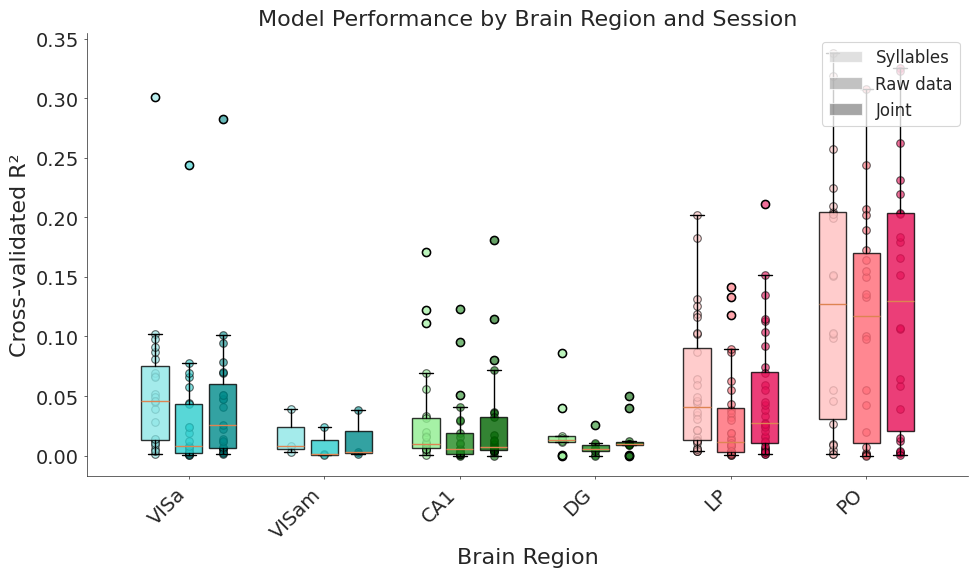

In [77]:
# Convert to DataFrame for easier plotting
results_df = pd.DataFrame(cv_results)

# Create the plot: brain areas on x-axis with individual session points
from statsmodels.stats.multitest import multipletests

# Increase font sizes globally
plt.rcParams.update({
    'font.size': 14,
    'axes.titlesize': 16,
    'axes.labelsize': 14,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'legend.fontsize': 12,
    'figure.titlesize': 18
})

# Or set specific font sizes for individual plots
fig, ax = plt.subplots(figsize=(10, 6))
ax.set_xlabel('Brain Region', fontsize=16)
ax.set_ylabel('Neural Activity', fontsize=16)
ax.set_title('Neural Activity by Brain Region', fontsize=18)
ax.tick_params(axis='both', which='major', labelsize=14)

# Define color schemes by brain region and model type
region_colors = {
    'VISa': ["#8EE7E7", "#2ECECE", '#008B8B'],    # Turquoise tones
    'VISam': ['#8EE7E7', '#2ECECE', '#008B8B'],   # Turquoise tones
    'CA1': ['#90EE90', '#228B22', '#006400'],     # Green tones
    'DG': ['#90EE90', '#228B22', '#006400'],      # Green tones
    'LP': ["#FFC0C0", "#FF6976", "#E70E56"],      # Pink tones
    'PO': ['#FFC0C0', '#FF6976', '#E70E56']       # Pink tones
}

# Create boxplot with individual points
# Plot for each model type
model_types = ['Syllables', 'Raw data', 'Joint']
for i, model_type in enumerate(model_types):
    model_data = results_df[results_df['model_type'] == model_type]
    
    # Create boxplot
    box_positions = np.arange(len(BRAIN_REGIONS)) + i * 0.25
    box_data = [model_data[model_data['brain_region'] == area]['mean_r2'].values 
                for area in BRAIN_REGIONS]
    
    bp = ax.boxplot(box_data, positions=box_positions, widths=0.2, 
                   patch_artist=True, labels=None)
    
    # Customize boxplot colors based on brain region
    for j, patch in enumerate(bp['boxes']):
        region = BRAIN_REGIONS[j]
        color = region_colors[region][i]  # i corresponds to model type (0=light, 1=medium, 2=dark)
        patch.set_facecolor(color)
        patch.set_alpha(0.8)
    
    # Add individual session points
    for j, area in enumerate(BRAIN_REGIONS):
        area_data = model_data[model_data['brain_region'] == area]['mean_r2']
        if len(area_data) > 0:
            x_pos = box_positions[j]
            y_pos = area_data.values
            color = region_colors[area][i]
            ax.scatter([x_pos] * len(y_pos), y_pos, 
                      alpha=0.6, s=30, color=color, edgecolors='black')

ax.set_xlabel('Brain Region')
ax.set_ylabel('Cross-validated R²')
ax.set_title('Model Performance by Brain Region and Session')
ax.set_xticks(np.arange(len(BRAIN_REGIONS)) + 0.25)
ax.set_xticklabels(BRAIN_REGIONS, rotation=45, ha='right')

# Add legend for model types
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#D3D3D3', alpha=0.7, label='Syllables'),
                   Patch(facecolor='#A9A9A9', alpha=0.7, label='Raw data'),
                   Patch(facecolor='#808080', alpha=0.7, label='Joint')]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()
fig.savefig(prefix+'representation_learning_variability/paper-individuality/figures/'+'fig1.1.svg', format='svg', bbox_inches='tight')


In [67]:
from statsmodels.stats.multitest import multipletests

# Filter for syllables and raw data only
plot_data = results_df[results_df['model_type'].isin(['Syllables', 'Raw data'])].copy()

# Statistical testing per brain region - PAIRED T-TESTS
brain_regions = plot_data['brain_region'].unique()
p_values = []
test_results = []

print("Statistical Tests (Paired t-tests: Syllables vs Raw Data per Region):")
print("=" * 70)

for region in brain_regions:
    region_data = plot_data[plot_data['brain_region'] == region]
    
    # Pivot to get paired data
    paired_data = region_data.pivot_table(
        index='session',  # or whatever identifies each sample
        columns='model_type', 
        values='mean_r2'
    ).dropna()
    
    if 'Syllables' in paired_data.columns and 'Raw data' in paired_data.columns:
        syllables = paired_data['Syllables']
        raw_data = paired_data['Raw data']
        
        # Paired t-test
        stat, p_val = stats.ttest_rel(syllables, raw_data)
        p_values.append(p_val)
        test_results.append({
            'region': region,
            'statistic': stat,
            'p_value': p_val,
            'n_pairs': len(syllables)
        })
        
        print(f"{region}: p = {p_val:.4f} (n = {len(syllables)} pairs)")

# Multiple comparison correction
if p_values:
    rejected, p_corrected, _, _ = multipletests(p_values, method='fdr_bh')
    
    print("\nAfter FDR correction:")
    print("-" * 30)
    for i, result in enumerate(test_results):
        result['p_corrected'] = p_corrected[i]
        result['significant'] = rejected[i]
        sig_marker = " *" if rejected[i] else ""
        print(f"{result['region']}: p = {p_corrected[i]:.4f}{sig_marker}")

plt.tight_layout()
plt.show()

Statistical Tests (Paired t-tests: Syllables vs Raw Data per Region):
VISa: p = 0.0000 (n = 23 pairs)
LP: p = 0.0002 (n = 32 pairs)
PO: p = 0.0032 (n = 22 pairs)
DG: p = 0.0415 (n = 10 pairs)
CA1: p = 0.0011 (n = 25 pairs)
VISam: p = 0.1369 (n = 3 pairs)

After FDR correction:
------------------------------
VISa: p = 0.0001 *
LP: p = 0.0006 *
PO: p = 0.0048 *
DG: p = 0.0498 *
CA1: p = 0.0022 *
VISam: p = 0.1369


<Figure size 640x480 with 0 Axes>

In [1]:
# Stack all sessions into a single dataframe
final_stacked_data = pd.concat(all_sessions_data, ignore_index=True)
print(f"Final stacked dataframe shape: {final_stacked_data.shape}")

NameError: name 'pd' is not defined

# Modelling 


Processing VISa...

Processing LP...

Processing PO...


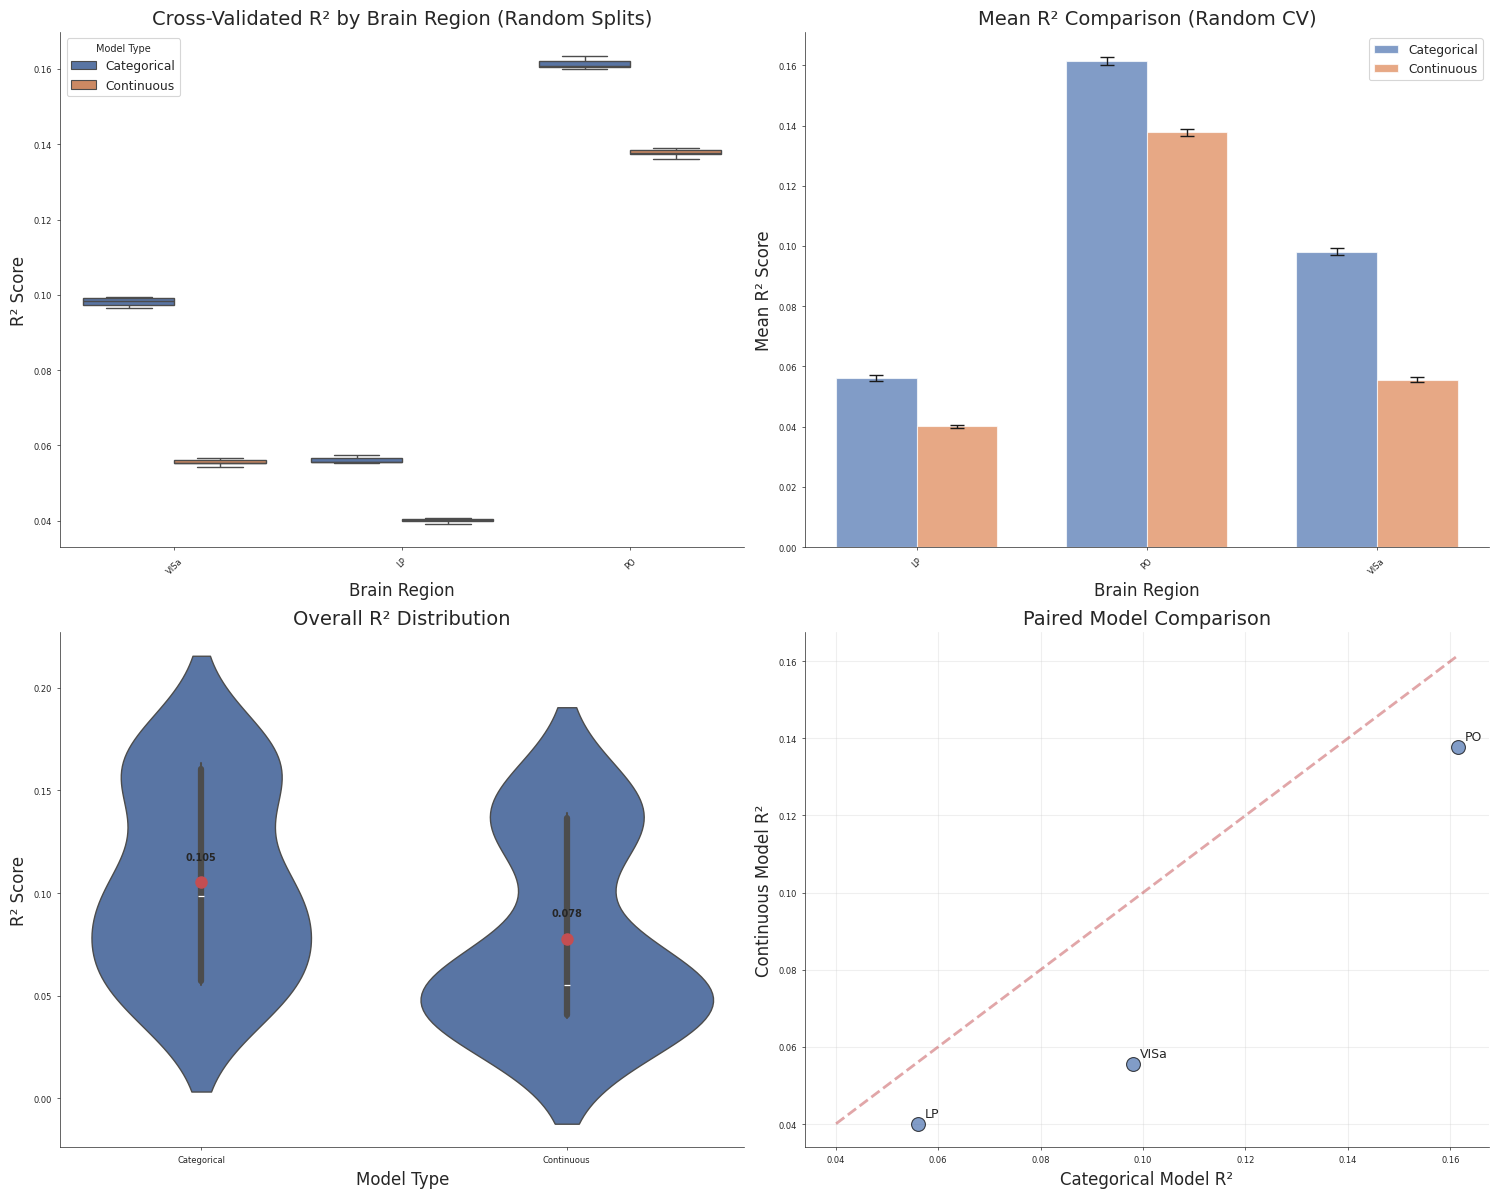


=== Model Comparison Summary (Random CV) ===
             count      mean       std       min       max
model_type                                                
Categorical     15  0.105221  0.044814  0.055407  0.163515
Continuous      15  0.077782  0.044353  0.039185  0.138954

=== Brain Region Specific Results ===
                              mean       std
brain_region model_type                     
LP           Categorical  0.056112  0.000912
             Continuous   0.040095  0.000600
PO           Categorical  0.161415  0.001403
             Continuous   0.137709  0.001152
VISa         Categorical  0.098135  0.001254
             Continuous   0.055543  0.000840

=== Statistical Comparison ===
Independent t-test: t=1.6854, p=0.1030
Paired t-test (region means): t=3.4753, p=0.0738
Cohen's d effect size: -0.6372


In [ ]:
warnings.filterwarnings('ignore')

# Prepare data for both models
# Model 1: Categorical variables (unchanged)
data_categorical = final_stacked_data.copy()
data_categorical['paw'] = data_categorical['paw'].astype('category')
data_categorical['whisk'] = data_categorical['whisk'].astype('category') 
data_categorical['lick'] = data_categorical['lick'].astype('category')

# Model 2: Continuous variables with paw velocities and categorical lick count
data_continuous = final_stacked_data.copy()
# Convert Lick count to categorical
data_continuous['Lick count'] = data_continuous['Lick count'].astype('category')

# Storage for results
cv_results = {
    'brain_region': [],
    'model_type': [],
    'r2_scores': [],
    'mean_r2': [],
    'std_r2': []}

# Compare models for each brain region
for area in BRAIN_REGIONS:
    spike_col = f'{area}_spike_count'
    
    if spike_col in final_stacked_data.columns:
        print(f"\nProcessing {area}...")
        
        # Categorical model (unchanged)
        cat_data = data_categorical.dropna(subset=['paw', 'whisk', 'lick', spike_col])
        if len(cat_data) > 50:  # Minimum sample size
            formula_cat = f'{spike_col} ~ paw + whisk + lick'
            r2_cat = calculate_cv_r2_random(cat_data, formula_cat, 'session_pid')
            
            if r2_cat:
                cv_results['brain_region'].extend([area] * len(r2_cat))
                cv_results['model_type'].extend(['Categorical'] * len(r2_cat))
                cv_results['r2_scores'].extend(r2_cat)
                cv_results['mean_r2'].extend([np.mean(r2_cat)] * len(r2_cat))
                cv_results['std_r2'].extend([np.std(r2_cat)] * len(r2_cat))
        
        # Continuous model with paw velocities and categorical lick count
        cont_data = data_continuous.dropna(subset=['l_paw_y_velocity', 'r_paw_x_velocity', 
                                                  'r_paw_y_velocity', 'r_paw_x_velocity', 
                                                  'whisker_me', 'Lick count', spike_col])
        if len(cont_data) > 50:  # Minimum sample size
            formula_cont = f'{spike_col} ~ l_paw_y_velocity + r_paw_x_velocity + r_paw_y_velocity + r_paw_x_velocity + whisker_me + C(Q("Lick count"))'
            r2_cont = calculate_cv_r2_random(cont_data, formula_cont, 'session_pid')
            
            if r2_cont:
                cv_results['brain_region'].extend([area] * len(r2_cont))
                cv_results['model_type'].extend(['Continuous'] * len(r2_cont))
                cv_results['r2_scores'].extend(r2_cont)
                cv_results['mean_r2'].extend([np.mean(r2_cont)] * len(r2_cont))
                cv_results['std_r2'].extend([np.std(r2_cont)] * len(r2_cont))




### Syllable, raw and joint model - across all sessions

In [106]:
# Prepare data for all three models
# Model 1: Categorical variables (unchanged)
data_categorical = final_stacked_data.copy()
data_categorical['paw'] = data_categorical['paw'].astype('category')
data_categorical['whisk'] = data_categorical['whisk'].astype('category') 
data_categorical['lick'] = data_categorical['lick'].astype('category')

# Model 2: Continuous variables with paw velocities and categorical lick count (unchanged)
data_continuous = final_stacked_data.copy()
data_continuous['Lick count'] = data_continuous['Lick count'].astype('category')

# Model 3: Joint model - combine categorical and continuous variables
data_joint = final_stacked_data.copy()
data_joint['whisk'] = data_joint['whisk'].astype('category')
data_joint['lick'] = data_joint['lick'].astype('category')
# Note: Using lick instead of Lick count to avoid redundancy, and excluding categorical paw 
# since we have continuous paw velocities

# Storage for results
cv_results = {
    'brain_region': [],
    'model_type': [],
    'r2_scores': [],
    'mean_r2': [],
    'std_r2': []}

# Compare models for each brain region
for area in BRAIN_REGIONS:
    spike_col = f'{area}_spike_count'
    
    if spike_col in final_stacked_data.columns:
        print(f"\nProcessing {area}...")
        
        # Categorical model (unchanged)
        cat_data = data_categorical.dropna(subset=['paw', 'whisk', 'lick', spike_col])
        if len(cat_data) > 50:
            formula_cat = f'{spike_col} ~ paw + whisk + lick'
            r2_cat = calculate_cv_r2_random(cat_data, formula_cat, 'session_pid')
            
            if r2_cat:
                cv_results['brain_region'].extend([area] * len(r2_cat))
                cv_results['model_type'].extend(['Categorical'] * len(r2_cat))
                cv_results['r2_scores'].extend(r2_cat)
                cv_results['mean_r2'].extend([np.mean(r2_cat)] * len(r2_cat))
                cv_results['std_r2'].extend([np.std(r2_cat)] * len(r2_cat))
        
        # Continuous model (unchanged)
        cont_data = data_continuous.dropna(subset=['l_paw_y_velocity', 'r_paw_x_velocity', 
                                                  'r_paw_y_velocity', 'r_paw_x_velocity', 
                                                  'whisker_me', 'Lick count', spike_col])
        if len(cont_data) > 50:
            formula_cont = f'{spike_col} ~ l_paw_y_velocity + r_paw_x_velocity + r_paw_y_velocity + r_paw_x_velocity + whisker_me + C(Q("Lick count"))'
            r2_cont = calculate_cv_r2_random(cont_data, formula_cont, 'session_pid')
            
            if r2_cont:
                cv_results['brain_region'].extend([area] * len(r2_cont))
                cv_results['model_type'].extend(['Continuous'] * len(r2_cont))
                cv_results['r2_scores'].extend(r2_cont)
                cv_results['mean_r2'].extend([np.mean(r2_cont)] * len(r2_cont))
                cv_results['std_r2'].extend([np.std(r2_cont)] * len(r2_cont))
        
        # Joint model - combines categorical and continuous variables
        joint_data = data_joint.dropna(subset=['l_paw_y_velocity', 'r_paw_x_velocity', 
                                              'r_paw_y_velocity', 'r_paw_x_velocity', 
                                              'whisker_me', 'whisk', 'lick', spike_col])
        if len(joint_data) > 50:
            formula_joint = f'{spike_col} ~ l_paw_y_velocity + r_paw_x_velocity + r_paw_y_velocity + r_paw_x_velocity + whisker_me + whisk + lick'
            r2_joint = calculate_cv_r2_random(joint_data, formula_joint, 'session_pid')
            
            if r2_joint:
                cv_results['brain_region'].extend([area] * len(r2_joint))
                cv_results['model_type'].extend(['Joint'] * len(r2_joint))
                cv_results['r2_scores'].extend(r2_joint)
                cv_results['mean_r2'].extend([np.mean(r2_joint)] * len(r2_joint))
                cv_results['std_r2'].extend([np.std(r2_joint)] * len(r2_joint))


Processing VISa...

Processing CA1...

Processing DG...

Processing LP...

Processing PO...


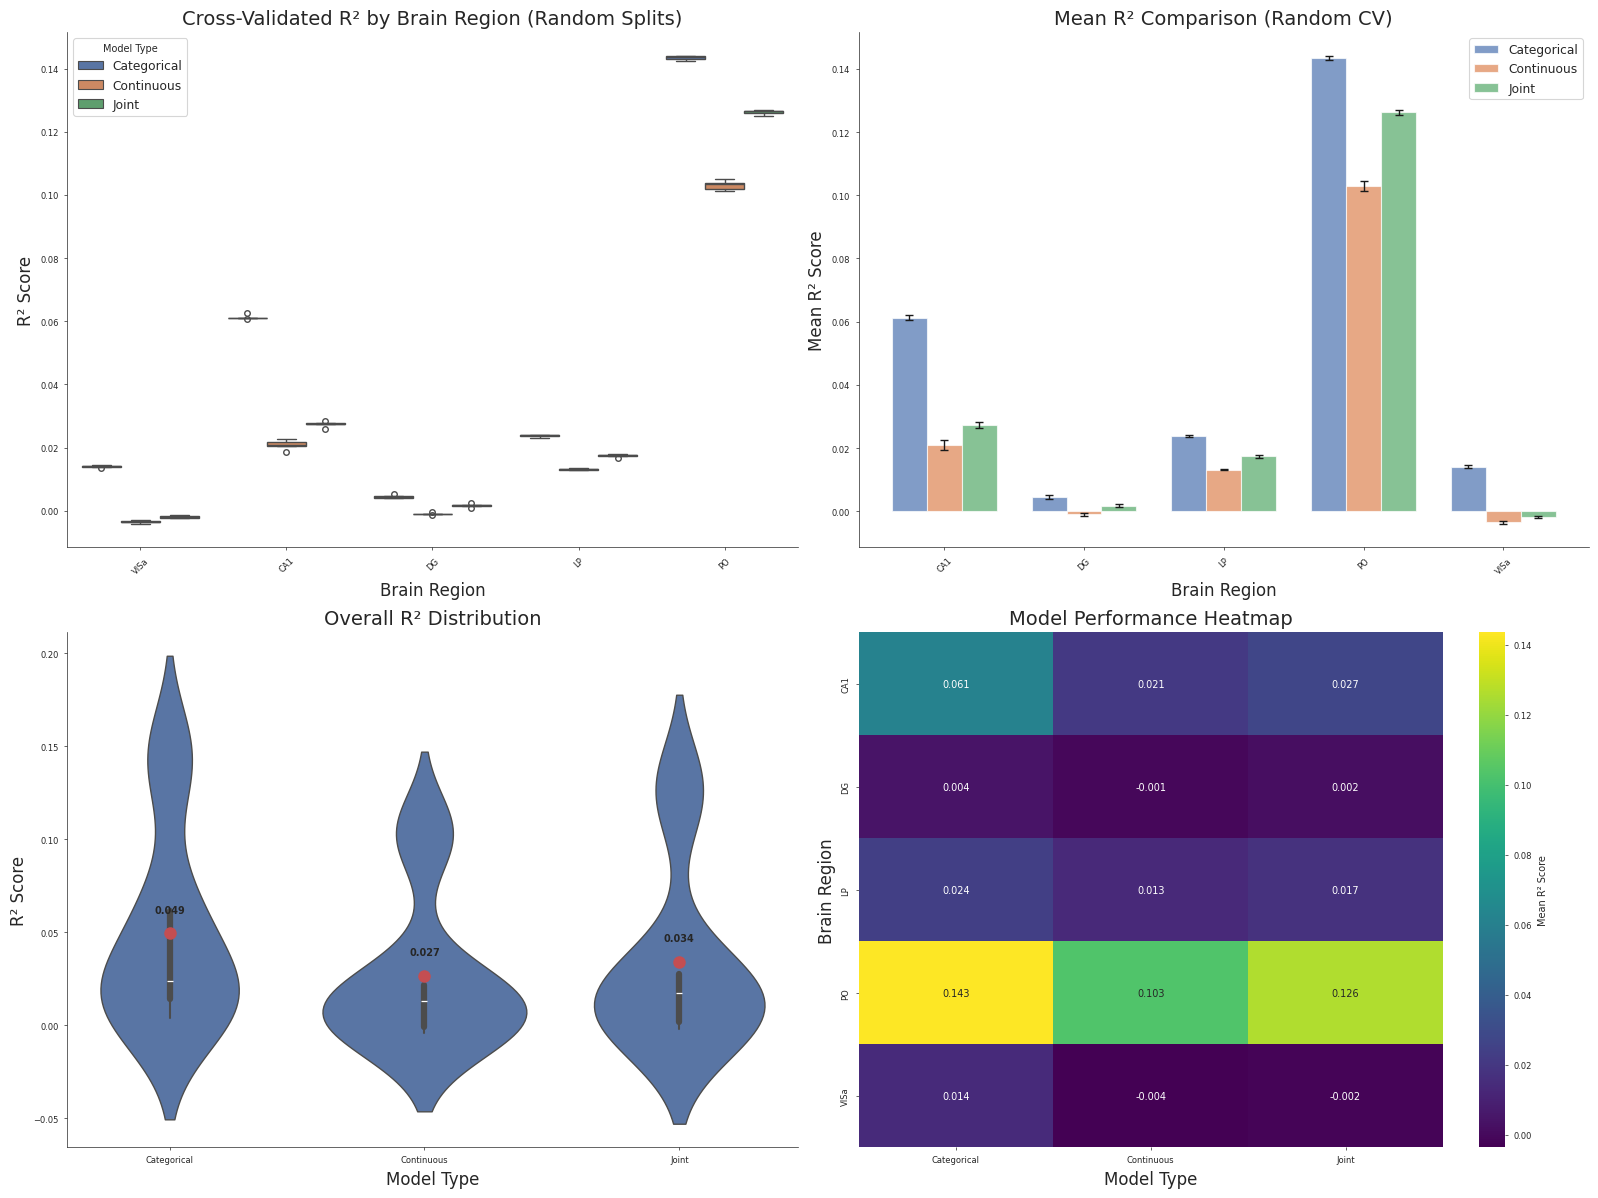


=== Model Comparison Summary (Random CV) ===
             count      mean       std       min       max
model_type                                                
Categorical     25  0.049392  0.051893  0.003957  0.144045
Continuous      25  0.026520  0.040122 -0.004106  0.104870
Joint           25  0.034154  0.048223 -0.002256  0.126951

=== Brain Region Specific Results ===
                              mean       std
brain_region model_type                     
CA1          Categorical  0.061288  0.000775
             Continuous   0.020904  0.001497
             Joint        0.027321  0.000956
DG           Categorical  0.004453  0.000526
             Continuous  -0.000982  0.000415
             Joint        0.001685  0.000497
LP           Categorical  0.023685  0.000354
             Continuous   0.013175  0.000258
             Joint        0.017422  0.000432
PO           Categorical  0.143485  0.000670
             Continuous   0.103031  0.001531
             Joint        0.126240 

In [107]:
""" PLOTTING """          
# Convert to DataFrame
cv_df = pd.DataFrame(cv_results)

if len(cv_df) > 0:
    # Create comparison plots - updated for 3 models
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # Plot 1: Box plot comparison by brain region
    ax1 = axes[0, 0]
    sns.boxplot(data=cv_df, x='brain_region', y='r2_scores', hue='model_type', ax=ax1)
    ax1.set_title('Cross-Validated R² by Brain Region (Random Splits)', fontsize=14)
    ax1.set_ylabel('R² Score', fontsize=12)
    ax1.set_xlabel('Brain Region', fontsize=12)
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend(title='Model Type')
    
    # Plot 2: Mean R² comparison with error bars - updated for 3 models
    ax2 = axes[0, 1]
    summary_stats = cv_df.groupby(['brain_region', 'model_type'])['r2_scores'].agg(['mean', 'std']).reset_index()
    
    brain_regions = summary_stats['brain_region'].unique()
    x = np.arange(len(brain_regions))
    width = 0.25  # Narrower bars for 3 models
    
    cat_data = summary_stats[summary_stats['model_type'] == 'Categorical']
    cont_data = summary_stats[summary_stats['model_type'] == 'Continuous']
    joint_data = summary_stats[summary_stats['model_type'] == 'Joint']
    
    ax2.bar(x - width, cat_data['mean'], width, yerr=cat_data['std'], 
            label='Categorical', alpha=0.7, capsize=3)
    ax2.bar(x, cont_data['mean'], width, yerr=cont_data['std'], 
            label='Continuous', alpha=0.7, capsize=3)
    ax2.bar(x + width, joint_data['mean'], width, yerr=joint_data['std'], 
            label='Joint', alpha=0.7, capsize=3)
    
    ax2.set_title('Mean R² Comparison (Random CV)', fontsize=14)
    ax2.set_ylabel('Mean R² Score', fontsize=12)
    ax2.set_xlabel('Brain Region', fontsize=12)
    ax2.set_xticks(x)
    ax2.set_xticklabels(brain_regions, rotation=45)
    ax2.legend()
    
    # Plot 3: Overall distribution comparison - updated for 3 models
    ax3 = axes[1, 0]
    sns.violinplot(data=cv_df, x='model_type', y='r2_scores', ax=ax3)
    ax3.set_title('Overall R² Distribution', fontsize=14)
    ax3.set_ylabel('R² Score', fontsize=12)
    ax3.set_xlabel('Model Type', fontsize=12)
    
    # Add mean markers
    means = cv_df.groupby('model_type')['r2_scores'].mean()
    for i, (model_type, mean_val) in enumerate(means.items()):
        ax3.plot(i, mean_val, 'ro', markersize=8)
        ax3.text(i, mean_val + 0.01, f'{mean_val:.3f}', 
                ha='center', va='bottom', fontweight='bold')
    
    # Plot 4: Model performance heatmap by brain region
    ax4 = axes[1, 1]
    
    # Create pivot table for heatmap
    pivot_data = cv_df.groupby(['brain_region', 'model_type'])['r2_scores'].mean().reset_index()
    heatmap_data = pivot_data.pivot(index='brain_region', columns='model_type', values='r2_scores')
    
    sns.heatmap(heatmap_data, annot=True, cmap='viridis', fmt='.3f', ax=ax4, 
                cbar_kws={'label': 'Mean R² Score'})
    ax4.set_title('Model Performance Heatmap', fontsize=14)
    ax4.set_xlabel('Model Type', fontsize=12)
    ax4.set_ylabel('Brain Region', fontsize=12)
    
    plt.tight_layout()
    plt.show()

    # ... existing summary statistics code ...

    # Print summary statistics
    print("\n=== Model Comparison Summary (Random CV) ===")
    summary = cv_df.groupby('model_type')['r2_scores'].agg(['count', 'mean', 'std', 'min', 'max'])
    print(summary)
    
    print("\n=== Brain Region Specific Results ===")
    region_summary = cv_df.groupby(['brain_region', 'model_type'])['r2_scores'].agg(['mean', 'std'])
    print(region_summary)
    
    # Statistical comparison
    from scipy.stats import ttest_rel, wilcoxon, ttest_ind
    
    print("\n=== Statistical Comparison ===")
    
    # Independent samples t-test (since we're using random splits)
    cat_scores_all = cv_df[cv_df['model_type'] == 'Categorical']['r2_scores'].values
    cont_scores_all = cv_df[cv_df['model_type'] == 'Continuous']['r2_scores'].values
    
    if len(cat_scores_all) > 0 and len(cont_scores_all) > 0:
        try:
            t_stat, t_pval = ttest_ind(cat_scores_all, cont_scores_all)
            print(f"Independent t-test: t={t_stat:.4f}, p={t_pval:.4f}")
        except:
            print("Could not perform independent t-test")
    
    # Paired comparison if available
    if len(paired_results) > 1:
        cat_paired = [paired_results[region]['categorical'] for region in paired_results.keys()]
        cont_paired = [paired_results[region]['continuous'] for region in paired_results.keys()]
        
        # Paired t-test for brain region means
        try:
            t_stat, t_pval = ttest_rel(cat_paired, cont_paired)
            print(f"Paired t-test (region means): t={t_stat:.4f}, p={t_pval:.4f}")
        except:
            print("Could not perform paired t-test")
        
        # Effect size (Cohen's d)
        pooled_std = np.sqrt(((len(cat_paired) - 1) * np.var(cat_paired) + 
                             (len(cont_paired) - 1) * np.var(cont_paired)) / 
                            (len(cat_paired) + len(cont_paired) - 2))
        cohens_d = (np.mean(cont_paired) - np.mean(cat_paired)) / pooled_std
        print(f"Cohen's d effect size: {cohens_d:.4f}")

else:
    print("No valid cross-validation results obtained. Check data availability and model specifications.")


## Syllable, raw and joint model per session and area


Processing VISa...
  Session: 0b8ea3ec-e75b-41a1-9442-64f5fbc11a5a
  Session: e42e948c-3154-45cb-bf52-408b7cda0f2f

Processing CA1...
  Session: 0b8ea3ec-e75b-41a1-9442-64f5fbc11a5a
  Session: e42e948c-3154-45cb-bf52-408b7cda0f2f

Processing DG...
  Session: 0b8ea3ec-e75b-41a1-9442-64f5fbc11a5a
  Session: e42e948c-3154-45cb-bf52-408b7cda0f2f

Processing LP...
  Session: 0b8ea3ec-e75b-41a1-9442-64f5fbc11a5a
  Session: e42e948c-3154-45cb-bf52-408b7cda0f2f

Processing PO...
  Session: 0b8ea3ec-e75b-41a1-9442-64f5fbc11a5a
  Session: e42e948c-3154-45cb-bf52-408b7cda0f2f


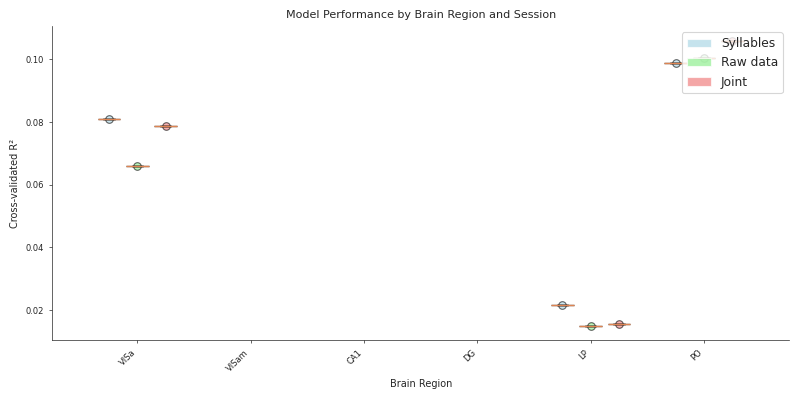


Summary Statistics:
                         count      mean  std
brain_region model_type                      
LP           Joint           1  0.015714  NaN
             Raw data        1  0.015097  NaN
             Syllables       1  0.021801  NaN
PO           Joint           1  0.105962  NaN
             Raw data        1  0.100554  NaN
             Syllables       1  0.098710  NaN
VISa         Joint           1  0.078708  NaN
             Raw data        1  0.066111  NaN
             Syllables       1  0.080826  NaN


In [ ]:
# Prepare data for all three models (same as before)
data_categorical = final_stacked_data.copy()
data_categorical['paw'] = data_categorical['paw'].astype('category')
data_categorical['whisk'] = data_categorical['whisk'].astype('category') 
data_categorical['lick'] = data_categorical['lick'].astype('category')

data_continuous = final_stacked_data.copy()
data_continuous['Lick count'] = data_continuous['Lick count'].astype('category')

data_joint = final_stacked_data.copy()
data_joint['whisk'] = data_joint['whisk'].astype('category')
data_joint['lick'] = data_joint['lick'].astype('category')

# Storage for results - now includes session
cv_results = {
    'brain_region': [],
    'session': [],
    'model_type': [],
    'mean_r2': []
}

# Compare models for each brain region and session separately
for area in BRAIN_REGIONS:
    spike_col = f'{area}_spike_count'
    
    if spike_col in final_stacked_data.columns:
        print(f"\nProcessing {area}...")
        
        # Get unique sessions for this brain region
        area_sessions = final_stacked_data['session_pid'].unique()
        
        for session in area_sessions:
            print(f"  Session: {session}")
            
            # Filter data for current session
            session_data_cat = data_categorical[data_categorical['session_pid'] == session]
            session_data_cont = data_continuous[data_continuous['session_pid'] == session]
            session_data_joint = data_joint[data_joint['session_pid'] == session]
            
            # Categorical model
            cat_data = session_data_cat.dropna(subset=['paw', 'whisk', 'lick', spike_col])
            if len(cat_data) > 50:  # Minimum data requirement
                formula_cat = f'{spike_col} ~ C(paw) + C(whisk) + C(lick)'
                # Now use random CV since we're within a single session
                r2_cat = calculate_cv_r2_random(cat_data, formula_cat, groups_col=None)
                
                if r2_cat:
                    cv_results['brain_region'].append(area)
                    cv_results['session'].append(session)
                    cv_results['model_type'].append('Syllables')
                    cv_results['mean_r2'].append(np.mean(r2_cat))
            
            # Continuous model
            cont_data = session_data_cont.dropna(subset=['l_paw_y_velocity', 'r_paw_x_velocity', 
                                                        'r_paw_y_velocity', 'r_paw_x_velocity', 
                                                        'whisker_me', 'Lick count', spike_col])
            if len(cont_data) > 50:
                formula_cont = f'{spike_col} ~ l_paw_y_velocity + r_paw_x_velocity + r_paw_y_velocity + r_paw_x_velocity + whisker_me + C(Q("Lick count"))'
                r2_cont = calculate_cv_r2_random(cont_data, formula_cont, groups_col=None)
                
                if r2_cont:
                    cv_results['brain_region'].append(area)
                    cv_results['session'].append(session)
                    cv_results['model_type'].append('Raw data')
                    cv_results['mean_r2'].append(np.mean(r2_cont))
            
            # Joint model
            joint_data = session_data_joint.dropna(subset=['l_paw_y_velocity', 'r_paw_x_velocity', 
                                                          'r_paw_y_velocity', 'r_paw_x_velocity', 
                                                          'whisker_me', 'whisk', 'lick', spike_col])
            if len(joint_data) > 50:
                formula_joint = f'{spike_col} ~ l_paw_y_velocity + r_paw_x_velocity + r_paw_y_velocity + r_paw_x_velocity + whisker_me + paw + whisk + lick'
                r2_joint = calculate_cv_r2_random(joint_data, formula_joint, groups_col=None)
                
                if r2_joint:
                    cv_results['brain_region'].append(area)
                    cv_results['session'].append(session)
                    cv_results['model_type'].append('Joint')
                    cv_results['mean_r2'].append(np.mean(r2_joint))

# Convert to DataFrame for easier plotting
results_df = pd.DataFrame(cv_results)

# Create the plot: brain areas on x-axis with individual session points
fig, ax = plt.subplots(figsize=(8, 4))

# Create boxplot with individual points
# Plot for each model type
for i, model_type in enumerate(['Syllables', 'Raw data', 'Joint']):
    model_data = results_df[results_df['model_type'] == model_type]
    
    # Create boxplot
    box_positions = np.arange(len(BRAIN_REGIONS)) + i * 0.25
    box_data = [model_data[model_data['brain_region'] == area]['mean_r2'].values 
                for area in BRAIN_REGIONS]
    
    bp = ax.boxplot(box_data, positions=box_positions, widths=0.2, 
                   patch_artist=True, labels=None)
    
    # Customize boxplot colors
    colors = ['lightblue', 'lightgreen', 'lightcoral']
    for patch in bp['boxes']:
        patch.set_facecolor(colors[i])
        patch.set_alpha(0.7)
    
    # Add individual session points
    for j, area in enumerate(BRAIN_REGIONS):
        area_data = model_data[model_data['brain_region'] == area]['mean_r2']
        if len(area_data) > 0:
            x_pos = box_positions[j]
            y_pos = area_data.values
            ax.scatter([x_pos] * len(y_pos), y_pos, 
                      alpha=0.6, s=30, color=colors[i], edgecolors='black')

ax.set_xlabel('Brain Region')
ax.set_ylabel('Cross-validated R²')
ax.set_title('Model Performance by Brain Region and Session')
ax.set_xticks(np.arange(len(BRAIN_REGIONS)) + 0.25)
ax.set_xticklabels(BRAIN_REGIONS, rotation=45, ha='right')

# Add legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], alpha=0.7, label=model_type) 
                   for i, model_type in enumerate(['Syllables', 'Raw data', 'Joint'])]
ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nSummary Statistics:")
print(results_df.groupby(['brain_region', 'model_type'])['mean_r2'].agg(['count', 'mean', 'std']))

## With shuffle control (need to see IBL literature)


Processing VISa...
  Session: 0b8ea3ec-e75b-41a1-9442-64f5fbc11a5a
  Session: e42e948c-3154-45cb-bf52-408b7cda0f2f
  Session: ce397420-3cd2-4a55-8fd1-5e28321981f4
  Session: e4ce2e94-6fb9-4afe-acbf-6f5a3498602e
  Session: b83407f8-8220-46f9-9b90-a4c9f150c572
  Session: 92822789-608f-44a6-ad64-fe549402b2df
  Session: f4bd76a6-66c9-41f3-9311-6962315f8fc8
  Session: 3d3d5a5e-df26-43ee-80b6-2d72d85668a5
  Session: e31b4e39-e350-47a9-aca4-72496d99ff2a
  Session: 6fc4d73c-2071-43ec-a756-c6c6d8322c8b
  Session: 4836a465-c691-4852-a0b1-dcd2b1ce38a1
  Session: 1e176f17-d00f-49bb-87ff-26d237b525f1
  Session: 92033a0c-5a14-471b-b131-d43c72ca5d7a
  Session: 16799c7a-e395-435d-a4c4-a678007e1550
  Session: b25799a5-09e8-4656-9c1b-44bc9cbb5279
  Session: c17772a9-21b5-49df-ab31-3017addea12e
  Session: 22212d26-a167-45fb-9963-35ecd003e8a2

Processing CA1...
  Session: 0b8ea3ec-e75b-41a1-9442-64f5fbc11a5a
  Session: e42e948c-3154-45cb-bf52-408b7cda0f2f
  Session: ce397420-3cd2-4a55-8fd1-5e28321981f4
 

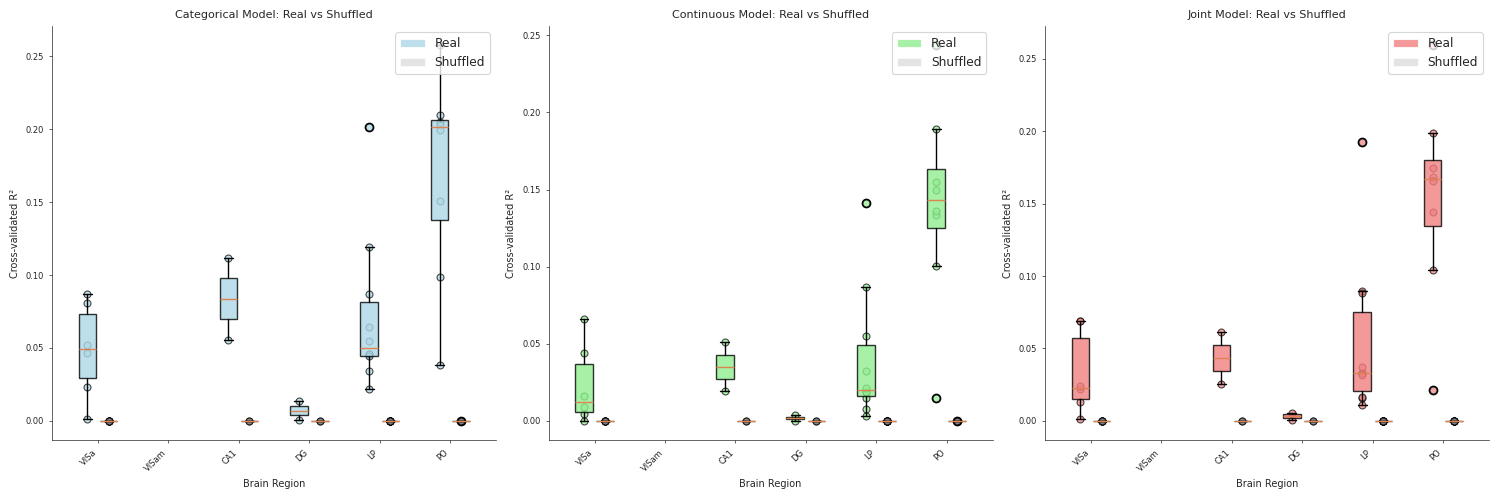


Summary Statistics - Real vs Shuffled:
                                    count      mean       std
brain_region model_type  condition                           
CA1          Categorical Real           2  0.083620  0.039680
                         Shuffled       2 -0.000051  0.000016
             Continuous  Real           2  0.035097  0.022358
                         Shuffled       2 -0.000037  0.000035
             Joint       Real           2  0.043582  0.025170
                         Shuffled       2 -0.000045  0.000027
DG           Categorical Real           2  0.007018  0.008834
                         Shuffled       2 -0.000084  0.000044
             Continuous  Real           2  0.001830  0.002425
                         Shuffled       2 -0.000040  0.000014
             Joint       Real           2  0.003143  0.003604
                         Shuffled       2 -0.000035  0.000049
LP           Categorical Real          10  0.071823  0.053497
                         Shuff

In [109]:
# Prepare data for all three models (same as before)
data_categorical = final_stacked_data.copy()
data_categorical['paw'] = data_categorical['paw'].astype('category')
data_categorical['whisk'] = data_categorical['whisk'].astype('category') 
data_categorical['lick'] = data_categorical['lick'].astype('category')

data_continuous = final_stacked_data.copy()
data_continuous['Lick count'] = data_continuous['Lick count'].astype('category')
data_joint = final_stacked_data.copy()
data_joint['whisk'] = data_joint['whisk'].astype('category')
data_joint['lick'] = data_joint['lick'].astype('category')

# Storage for results - now includes session and shuffle control
cv_results = {
    'brain_region': [],
    'session': [],
    'model_type': [],
    'condition': [],  # 'Real' or 'Shuffled'
    'mean_r2': []
}

# Compare models for each brain region and session separately
for area in BRAIN_REGIONS:
    spike_col = f'{area}_spike_count'
    
    if spike_col in final_stacked_data.columns:
        print(f"\nProcessing {area}...")
        
        # Get unique sessions for this brain region
        area_sessions = final_stacked_data['session_pid'].unique()
        
        for session in area_sessions:
            print(f"  Session: {session}")
            
            # Filter data for current session
            session_data_cat = data_categorical[data_categorical['session_pid'] == session]
            session_data_cont = data_continuous[data_continuous['session_pid'] == session]
            session_data_joint = data_joint[data_joint['session_pid'] == session]
            
            # Categorical model - Real and Shuffled
            cat_data = session_data_cat.dropna(subset=['paw', 'whisk', 'lick', spike_col])
            if len(cat_data) > 50:  # Minimum data requirement
                formula_cat = f'{spike_col} ~ paw + whisk + lick'
                
                # Real data
                r2_cat_real = calculate_cv_r2_random(cat_data, formula_cat, groups_col=None)
                if r2_cat_real:
                    cv_results['brain_region'].append(area)
                    cv_results['session'].append(session)
                    cv_results['model_type'].append('Categorical')
                    cv_results['condition'].append('Real')
                    cv_results['mean_r2'].append(np.mean(r2_cat_real))
                
                # Shuffled data
                cat_data_shuffled = cat_data.copy()
                cat_data_shuffled[spike_col] = np.random.permutation(cat_data_shuffled[spike_col].values)
                r2_cat_shuffled = calculate_cv_r2_random(cat_data_shuffled, formula_cat, groups_col=None)
                if r2_cat_shuffled:
                    cv_results['brain_region'].append(area)
                    cv_results['session'].append(session)
                    cv_results['model_type'].append('Categorical')
                    cv_results['condition'].append('Shuffled')
                    cv_results['mean_r2'].append(np.mean(r2_cat_shuffled))
            
            # Continuous model - Real and Shuffled
            cont_data = session_data_cont.dropna(subset=['l_paw_y_velocity', 'r_paw_x_velocity', 
                                                        'r_paw_y_velocity', 'r_paw_x_velocity', 
                                                        'whisker_me', 'Lick count', spike_col])
            if len(cont_data) > 50:
                formula_cont = f'{spike_col} ~ l_paw_y_velocity + r_paw_x_velocity + r_paw_y_velocity + r_paw_x_velocity + whisker_me + C(Q("Lick count"))'
                
                # Real data
                r2_cont_real = calculate_cv_r2_random(cont_data, formula_cont, groups_col=None)
                if r2_cont_real:
                    cv_results['brain_region'].append(area)
                    cv_results['session'].append(session)
                    cv_results['model_type'].append('Continuous')
                    cv_results['condition'].append('Real')
                    cv_results['mean_r2'].append(np.mean(r2_cont_real))
                
                # Shuffled data
                cont_data_shuffled = cont_data.copy()
                cont_data_shuffled[spike_col] = np.random.permutation(cont_data_shuffled[spike_col].values)
                r2_cont_shuffled = calculate_cv_r2_random(cont_data_shuffled, formula_cont, groups_col=None)
                if r2_cont_shuffled:
                    cv_results['brain_region'].append(area)
                    cv_results['session'].append(session)
                    cv_results['model_type'].append('Continuous')
                    cv_results['condition'].append('Shuffled')
                    cv_results['mean_r2'].append(np.mean(r2_cont_shuffled))
            
            # Joint model - Real and Shuffled
            joint_data = session_data_joint.dropna(subset=['l_paw_y_velocity', 'r_paw_x_velocity', 
                                                          'r_paw_y_velocity', 'r_paw_x_velocity', 
                                                          'whisker_me', 'whisk', 'lick', spike_col])
            if len(joint_data) > 50:
                formula_joint = f'{spike_col} ~ l_paw_y_velocity + r_paw_x_velocity + r_paw_y_velocity + r_paw_x_velocity + whisker_me + whisk + lick'
                
                # Real data
                r2_joint_real = calculate_cv_r2_random(joint_data, formula_joint, groups_col=None)
                if r2_joint_real:
                    cv_results['brain_region'].append(area)
                    cv_results['session'].append(session)
                    cv_results['model_type'].append('Joint')
                    cv_results['condition'].append('Real')
                    cv_results['mean_r2'].append(np.mean(r2_joint_real))
                
                # Shuffled data
                joint_data_shuffled = joint_data.copy()
                joint_data_shuffled[spike_col] = np.random.permutation(joint_data_shuffled[spike_col].values)
                r2_joint_shuffled = calculate_cv_r2_random(joint_data_shuffled, formula_joint, groups_col=None)
                if r2_joint_shuffled:
                    cv_results['brain_region'].append(area)
                    cv_results['session'].append(session)
                    cv_results['model_type'].append('Joint')
                    cv_results['condition'].append('Shuffled')
                    cv_results['mean_r2'].append(np.mean(r2_joint_shuffled))

# Convert to DataFrame for easier plotting
results_df = pd.DataFrame(cv_results)

# Create the plot: brain areas on x-axis with real vs shuffled comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
model_types = ['Categorical', 'Continuous', 'Joint']
colors = ['lightblue', 'lightgreen', 'lightcoral']

for idx, model_type in enumerate(model_types):
    ax = axes[idx]
    model_data = results_df[results_df['model_type'] == model_type]
    
    # Separate real and shuffled data
    real_data = model_data[model_data['condition'] == 'Real']
    shuffled_data = model_data[model_data['condition'] == 'Shuffled']
    
    # Create boxplots
    box_positions_real = np.arange(len(BRAIN_REGIONS)) - 0.15
    box_positions_shuffled = np.arange(len(BRAIN_REGIONS)) + 0.15
    
    # Real data boxplot
    box_data_real = [real_data[real_data['brain_region'] == area]['mean_r2'].values 
                     for area in BRAIN_REGIONS]
    bp_real = ax.boxplot(box_data_real, positions=box_positions_real, widths=0.25, 
                        patch_artist=True, labels=None)
    
    # Shuffled data boxplot  
    box_data_shuffled = [shuffled_data[shuffled_data['brain_region'] == area]['mean_r2'].values 
                         for area in BRAIN_REGIONS]
    bp_shuffled = ax.boxplot(box_data_shuffled, positions=box_positions_shuffled, widths=0.25, 
                            patch_artist=True, labels=None)
    
    # Customize colors
    for patch in bp_real['boxes']:
        patch.set_facecolor(colors[idx])
        patch.set_alpha(0.8)
    for patch in bp_shuffled['boxes']:
        patch.set_facecolor('lightgray')
        patch.set_alpha(0.6)
    
    # Add individual points
    for j, area in enumerate(BRAIN_REGIONS):
        # Real data points
        area_real = real_data[real_data['brain_region'] == area]['mean_r2']
        if len(area_real) > 0:
            ax.scatter([box_positions_real[j]] * len(area_real), area_real.values, 
                      alpha=0.7, s=25, color=colors[idx], edgecolors='black')
        
        # Shuffled data points
        area_shuffled = shuffled_data[shuffled_data['brain_region'] == area]['mean_r2']
        if len(area_shuffled) > 0:
            ax.scatter([box_positions_shuffled[j]] * len(area_shuffled), area_shuffled.values, 
                      alpha=0.7, s=25, color='gray', edgecolors='black')
    
    ax.set_xlabel('Brain Region')
    ax.set_ylabel('Cross-validated R²')
    ax.set_title(f'{model_type} Model: Real vs Shuffled')
    ax.set_xticks(np.arange(len(BRAIN_REGIONS)))
    ax.set_xticklabels(BRAIN_REGIONS, rotation=45, ha='right')
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=colors[idx], alpha=0.8, label='Real'),
        Patch(facecolor='lightgray', alpha=0.6, label='Shuffled')
    ]
    ax.legend(handles=legend_elements, loc='upper right')

plt.tight_layout()
plt.show()

# Print summary statistics comparing real vs shuffled
print("\nSummary Statistics - Real vs Shuffled:")
print(results_df.groupby(['brain_region', 'model_type', 'condition'])['mean_r2'].agg(['count', 'mean', 'std']))

# Statistical comparison (paired t-test where possible)
print("\nStatistical Comparison (Real vs Shuffled):")
for area in BRAIN_REGIONS:
    for model_type in model_types:
        real_vals = results_df[(results_df['brain_region'] == area) & 
                              (results_df['model_type'] == model_type) & 
                              (results_df['condition'] == 'Real')]['mean_r2'].values
        shuffled_vals = results_df[(results_df['brain_region'] == area) & 
                                  (results_df['model_type'] == model_type) & 
                                  (results_df['condition'] == 'Shuffled')]['mean_r2'].values
        
        if len(real_vals) > 0 and len(shuffled_vals) > 0:
            from scipy.stats import ttest_ind
            stat, p_val = ttest_ind(real_vals, shuffled_vals)
            print(f"{area} - {model_type}: Real mean={np.mean(real_vals):.4f}, "
                  f"Shuffled mean={np.mean(shuffled_vals):.4f}, p={p_val:.4f}")